In [1]:
import jax
import jax.numpy as jnp
from jax import grad, jit, vmap, lax
import optax
import jax.scipy.integrate as integrate
jax.config.update("jax_enable_x64", True)

import matplotlib.pyplot as plt

from IPython.display import clear_output

First we must define the parameters of the model and the gradient descent parameters. See section 2 of arxiv/2202.11102 for more details on the potential and parameters. We also specify he form of the supercritical bubble profile h_SC and use this to create an initial path h_init which interpolates between the false vacuum (here given by h =1) and the supercritical bubble. For defect-catalysed transitions the initial configuration on the path must be the defect profile, not the false vacuum. This example shows how the MPT algorithm takes configurations which are not O(4) symmetric and converges to an O(4) symmetric solution, which is expected from the usual vacuum decay calculations

In [2]:
# Define parameter values - lam sets the overall scale of the potential, while eps controls the depth of the true vacuum and thus the strength of the phase transition
lam, eps = .5, .06

# Define grids and path
Tc, Rc = 14, 14,   # Radii of supercritical bubble in t and r directions
Lk,  Lr, Lt = 30, 100, 100      # Number of points along path, t, and r directions
r_1d, t_1d  = jnp.linspace(1e-3, 2*Rc, Lr), jnp.linspace(0, 2*Tc, Lt)     # 1d arrays of points grid
dt, dr = t_1d[1] - t_1d[0], r_1d[1] - r_1d[0]   # Grid spacings
t_grid, r_grid = jnp.meshgrid(t_1d, r_1d)       # Create 2D grid for t and r
r_sq = r_grid**2    # Squared r grid, which appears in the action integral

# Supercritical bubble ansatz for initialization
def h_SC(r, R, t, T): 
    return  jnp.tanh( ((r/R)**2 + (t/T)**2)  )

# Initialize path from false vacuum solution to the supercritical bubble solution. The path is a list of 2D field configurations
# The path starts with the false vacuum (h = 1) solution and ends with the supercritical bubble solution, with linear interpolation in between.
h_init = jnp.ones((Lk, Lr, Lt))
for k in range(Lk):
    # Choosing different coefficients cr, ct controls the shape of the field configurations, which initially will not have O(4) symmetry if cr != ct
    # We will see that the MPT algorithm converges to an O(4) symmetric solution, finding the optimal path even from this non-symmetric initialisation
    cr, ct = k/(Lk-1), (k/(Lk-1))**2
    if k> 0:
        h_init = h_init.at[k].set(h_SC(r_grid, cr*Rc, t_grid, ct*Tc))

# SGD parameters. The algorithm is very sensitive to the learning rate, and will diverge if the learning rate is too high
learning_rate = 5*1e-5
max_iterations = 10000

# Spread function for updates - controls how much to update each configuration along the path based on its distance from the configuration with the highest action
def spread(k, kmax): 
    return jnp.where(k < kmax,  k/kmax, 1 - (k-kmax)/(Lk-kmax - 1) )

Here we calculate the action for a given field configuration h, and it's gradients which are later used in the gradient descent step. We also calculate the action of the supercritical profile, which must be negative to have a valid starting point. If not, the radii Rc and Tc should be increased, or a different form of h_SC used

In [3]:
 @jit
def compute_action(h):
    
    # Use JAX for automatic differentiation of spatial derivatives
    dh_dr = jnp.gradient(h, dr, axis=0)
    dh_dt = jnp.gradient(h, dt, axis=1)
    
    # The potential. This parametrisation ensures the false minimum is at h=1 and the true minimum is at h=0
    #  epsilon controls the depth of the true minimum, subtracting epsilon ensures the potential at the false minimum is zero (i.e. we are calculating the action relative to the false vacuum)
    V = lam*(.5*h**2 - (1 - 3*eps/lam) * h**4 + 0.5 * (1- 4*eps/lam) * h**6 ) - eps 
    
    # Lagrangian density
    L = 2 *jnp.pi * r_sq * ( (dh_dt**2 + dh_dr**2) + 2*V) 

    # Integrate Lagrangian density using trapezoid rule
    action = jnp.trapezoid(jnp.trapezoid(L, r_1d, axis=0), t_1d, axis=0)
    
    return action

# Vectorize to compute action for all configs in path simultaneously
compute_action_path = jit(vmap(compute_action, in_axes=0))

# Compute gradients of action with respect to field configurations
grad_action = jit(grad(compute_action))

compute_action(h_SC(r_grid, Rc, t_grid, Tc))

Array(-256.3081453, dtype=float64)

This defines the update step and performs the SGD run. The masks ensure we fix the asymptotic boundary conditions for h. This ensures the algorithm finds a tunnelling profile, rather than the true or false vacuum solutions

In [4]:
# Create mask (1 = can update, 0 = boundary) to ensure we don't update the boundary values of fields
mask = jnp.ones((Lr, Lt))
mask = mask.at[-1, :].set(0.0)
mask = mask.at[:, -1].set(0.0)

# Training loop with JIT-compiled update step, varying by decreasing action
@jit
def update_step_actions(h_path):
    actions = compute_action_path(h_path)
    kmax = jnp.argmax(actions)
    h = h_path[kmax] # Configuration with highest action

    # Compute gradients of action with respect to field configurations and applies mask
    grads = grad_action(h)
    grads = jax.tree.map(lambda g, m: g * m, grads, mask)

    # Vectorized update for all k (except endpoints)
    spread_factors = vmap(lambda k: spread(k, kmax))(jnp.arange(Lk))    # Compute spread factors for all configurations in path
    update = - learning_rate * spread_factors[:, None, None] * grads    # Updates for each profile, scaled by spread factors
    h_path = h_path.at[1:-1].add(update[1:-1])  # Update path with scaled gradients, keeping endpoints fixed

    return h_path, kmax, actions # Returns new path, as well as actions for monitoring convergence

max_actions = []    # Create List to store max action for plotting and to monitor convergence
h_path = h_init     # Initialize h_path

# Main loop with updates from minimising action
for iteration in range(max_iterations):
    
    h_path, kmax, actions = update_step_actions(h_path)
    max_actions.append(actions[kmax])
    if actions[kmax] <1 or jnp.isnan(actions[kmax]): break   # Break conditions if action is effectively zero or diverges
    
    clear_output(wait=True)
    if iteration % 100 == 0:
        print(f"Iteration {iteration}, Action: {actions[kmax]:.6f}, Index: {kmax}")     # Monitors progress every 100 iterations

Iteration 9900, Action: 60.188508, Index: 17


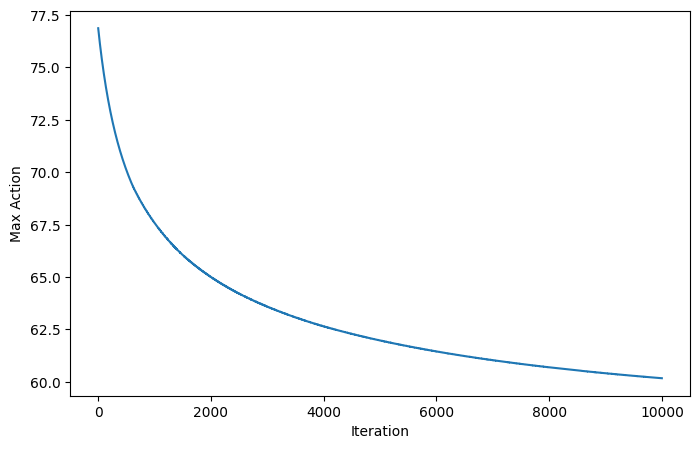

In [5]:
# Action as a function of iteration, which should decrease and converge to a minimum as the algorithm finds the optimal tunnelling solution
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(max_actions)
ax.set_xlabel("Iteration")
ax.set_ylabel("Max Action")
plt.show()

Plots initial and final configurations, showing convergence to the critical bubble solution which has O(4) symmetry, even from a non-symmetric initialisation. The plots show that the final profile has an O(4) symmety, as can be seen as the contours are in the same direction as the semi-circle drawn in red. This breaks down near r = 0 because the action is propoertional to r^2, so the algorithm doesn't update this region efficiently. However, this is also the region that contributes the least to the action, so it doesn't dramatically affect the accuracy of the final action value, and can be rectified by using a numerical PDE solver to solve for a small correction to the profiles found here, as was done in arxiv/2202.11102 and arxiv/2312.06749

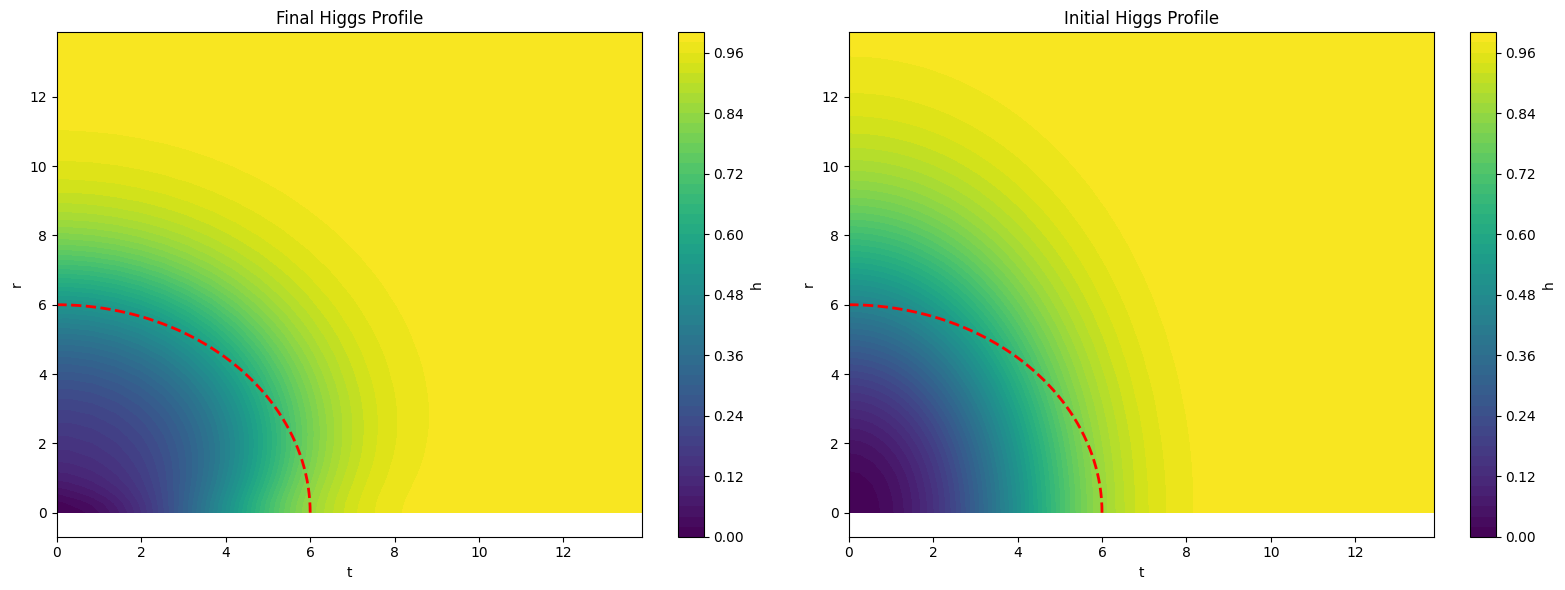

In [6]:
# Trims grid to show region around bubble for better visualisation
# The full grid must be big enough to containt the supercritical bubble, so is much larger than the region of interest around the critical bubble
ind_slice = slice(0, 50)
trimmed_h_final = h_path[kmax][ind_slice, ind_slice]
trimmed_h_init = h_init[kmax][ind_slice, ind_slice]
trimmed_r_grid = r_grid[ind_slice, ind_slice]
trimmed_t_grid = t_grid[ind_slice, ind_slice]

# Plots initial and final configurations
fig, ax = plt.subplots(1, 2, figsize=(16, 6))
cont0 = ax[0].contourf(trimmed_t_grid, trimmed_r_grid, trimmed_h_final, levels=50)
fig.colorbar(cont0, ax=ax[0], label='h')
ax[0].set_xlabel('t')
ax[0].set_ylabel('r')
ax[0].set_title('Final Higgs Profile')

cont1 = ax[1].contourf(trimmed_t_grid, trimmed_r_grid, trimmed_h_init, levels=50)
fig.colorbar(cont1, ax=ax[1], label='h')
ax[1].set_xlabel('t')
ax[1].set_ylabel('r')
ax[1].set_title('Initial Higgs Profile')

# Center (0,0) assumed; adjust if needed
theta = jnp.linspace(0, jnp.pi/2, 200)
t_semicircle = 6 * jnp.cos(theta)
r_semicircle = 6 * jnp.sin(theta)
# Overlay semicircle on both axes
ax[0].plot(t_semicircle, r_semicircle, 'r--', linewidth=2)
ax[1].plot(t_semicircle, r_semicircle, 'r--', linewidth=2)

plt.tight_layout()
plt.show()